
# Data Visualization with Matplotlib - Exercises 2

จงทำตามคำสั่งต่อไปนี้ด้วย data ที่กำหนดให้ต่อไปนี้


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## อ่านไฟล์ Superstore.csv

In [2]:
df = pd.read_csv('Superstore.csv',encoding = 'iso-8859-1')

In [3]:
df.head()

,Order ID,Customer Name,Segment,Day,Month,Year,Ship Mode,City,State,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,Claire Gute,Consumer,8,11,2016,Second Class,Henderson,Kentucky,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,Claire Gute,Consumer,8,11,2016,Second Class,Henderson,Kentucky,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2016-138688,Darrin Van Huff,Corporate,12,6,2016,Second Class,Los Angeles,California,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2015-108966,Sean O'Donnell,Consumer,11,10,2015,Standard Class,Fort Lauderdale,Florida,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2015-108966,Sean O'Donnell,Consumer,11,10,2015,Standard Class,Fort Lauderdale,Florida,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Customer Name  9994 non-null   object 
 2   Segment        9994 non-null   object 
 3   Day            9994 non-null   int64  
 4   Month          9994 non-null   int64  
 5   Year           9994 non-null   int64  
 6   Ship Mode      9994 non-null   object 
 7   City           9994 non-null   object 
 8   State          9994 non-null   object 
 9   Category       9994 non-null   object 
 10  Sub-Category   9994 non-null   object 
 11  Product Name   9994 non-null   object 
 12  Sales          9994 non-null   float64
 13  Quantity       9994 non-null   int64  
 14  Discount       9994 non-null   float64
 15  Profit         9994 non-null   float64
dtypes: float64(3), int64(4), object(9)
memory usage: 1.2+ MB


## Exercise 1

จงวาดกราฟแท่งแสดงรายได้ของปี 2014 - 2017 และตกแต่งให้สวยงาม


In [5]:
df[df['Year'].apply(lambda x: x in range(2014, 2018))].groupby('Year')['Sales'].sum()

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

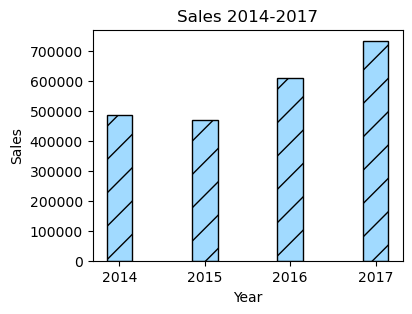

In [6]:
x = df[df['Year'].apply(lambda x: x in range(2014, 2018))].groupby('Year')['Sales'].sum()
plt.figure(figsize=(4, 3))
plt.bar(x.index, x.values, color='#A1DAFF',width=0.3,hatch='/',ec='k')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.xticks([2014,2015,2016,2017])
plt.title('Sales 2014-2017')
plt.show()

## Exercise 2

จงวาดกราฟวงกลม แสดงเปอร์เซ็นต์การขนส่งแต่ละแบบ ( Ship Mode ) พร้อมตกแต่งให้สวยงาม

In [7]:
df['Ship Mode'].unique()

array(['Second Class', 'Standard Class', 'First Class', 'Same Day'],
      dtype=object)

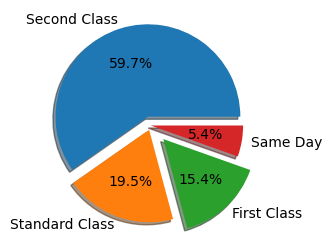

In [8]:
plt.figure(figsize = [4,3])
data = df['Ship Mode'].value_counts()
lb = ['Second Class', 'Standard Class', 'First Class', 'Same Day']
plt.pie(data,labels=lb,explode=[0.1,0.05,0.2,0],shadow=True,autopct="%.1f%%")
plt.show()

## Exercise 3

จงวาดกราฟความถี่นับจำนวนส่วนลด (Discount) พร้อมตกแต่งให้สวยงาม

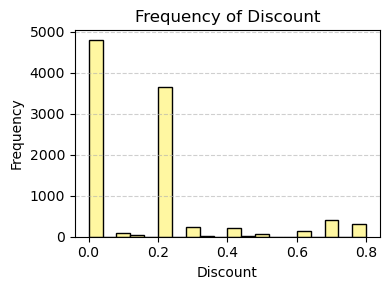

In [9]:
plt.figure(figsize=[4,3])

data = df['Discount']

plt.hist(data,bins=20,ec='k',color='#FFF7A1')
plt.xlabel('Discount')
plt.ylabel('Frequency')
plt.title('Frequency of Discount')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## Exercise 4

จงวาดกราฟจุด(Scatter) แสดงราคาขายกับกำไรที่ได้ (Sales , Profit) พร้อมตกแต่งให้สวยงาม

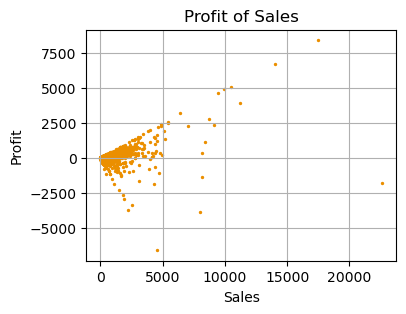

In [10]:
x = df['Sales']
y = df['Profit']
plt.figure(figsize = [4,3])
plt.scatter(x,y,s=2,color='#EB8F00')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.title('Profit of Sales')
plt.grid() ##draw the line 
plt.show()

## Exercise 5

จงวาดกราฟแท่งแสดงรายได้ของปี 2014 - 2017 ของแต่ละหมวดหมู่ในกราฟเดียว(แกน x เป็นปี) พร้อมตกแต่งให้สวยงาม

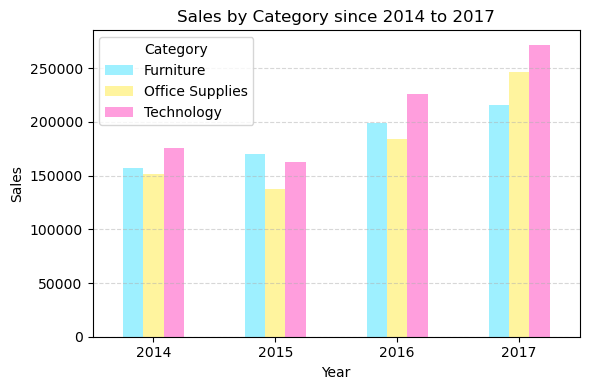

In [11]:
data = df[df['Year'].apply(lambda x: x in range(2014, 2018))]
pivot_data = data.pivot_table(values='Sales',index='Year',columns='Category', aggfunc='sum')
color = ['#9EF0FF','#FFF49E','#FF9EDD']
pivot_data.plot(kind='bar', figsize=(6,4),color=color) ###use pandas for plot the bar chart so easy0_o why i didn't know it before!

plt.xlabel('Year')
plt.ylabel('Sales')
plt.title('Sales by Category since 2014 to 2017')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Exercise 6

จงวาดกราฟแท่งแสดงรายได้ของแต่ละหมวด ตั้งแต่ปี 2014-2017 แบบแยกกราฟ (1หมวด 1กราฟ) พร้อมตกแต่งให้สวยงาม

In [12]:
pivot_data

Category,Furniture,Office Supplies,Technology
Year,,,
2014,157192.8531,151776.412,175278.233
2015,170518.2370,137233.463,162780.809
2016,198901.4360,183939.982,226364.180
2017,215387.2692,246097.175,271730.811


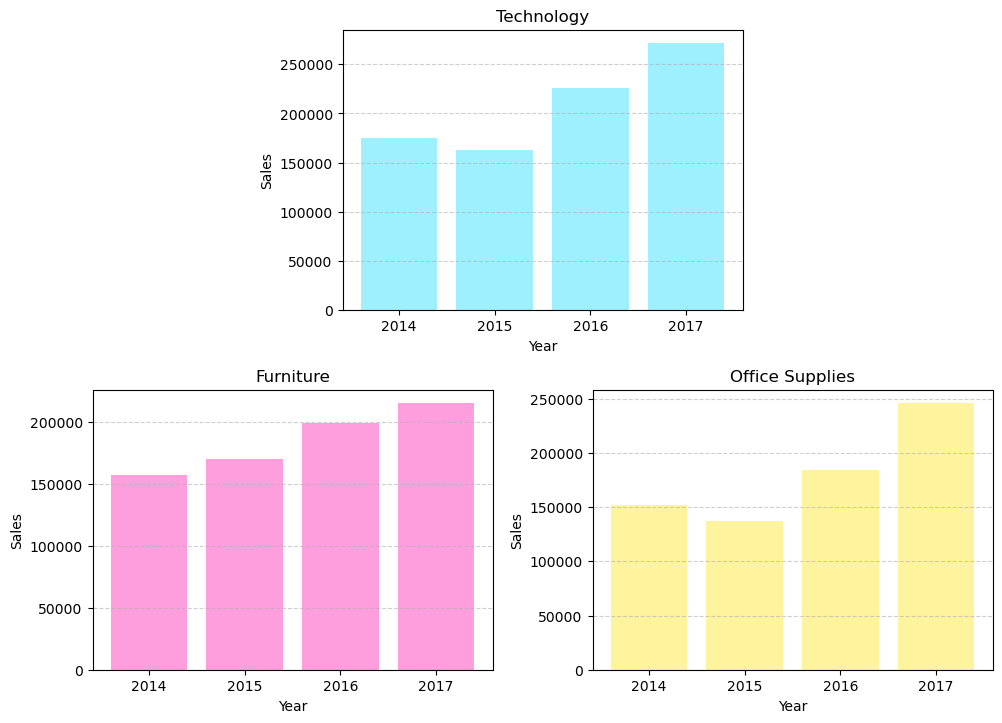

In [13]:
data = df[df['Year'].apply(lambda x: x in range(2014, 2018))]
pivot_data = data.pivot_table(values='Sales',index='Year',columns='Category', aggfunc='sum')

fig = plt.figure(figsize=(10, 8))

ax_tech = fig.add_axes([0.3, 0.55, 0.4, 0.35])
tech = pivot_data['Technology']
ax_tech.bar(tech.index, tech.values, color='#9EF0FF')
ax_tech.set_title('Technology')
ax_tech.set_xticks([2014, 2015, 2016, 2017])
ax_tech.grid(axis='y', ls='--', alpha=0.6)
ax_tech.set_xlabel('Year')
ax_tech.set_ylabel('Sales')


ax_fur = fig.add_axes([0.05, 0.1, 0.4, 0.35])
fur = pivot_data['Furniture']
ax_fur.bar(fur.index, fur.values, color='#FF9EDD')
ax_fur.set_title('Furniture')
ax_fur.set_xticks([2014, 2015, 2016, 2017])
ax_fur.grid(axis='y', ls='--', alpha=0.6)
ax_fur.set_xlabel('Year')
ax_fur.set_ylabel('Sales')


ax_off = fig.add_axes([0.55, 0.1, 0.4, 0.35])
off = pivot_data['Office Supplies']
ax_off.bar(off.index, off.values, color='#FFF49E')
ax_off.set_title('Office Supplies')
ax_off.set_xticks([2014, 2015, 2016, 2017])
ax_off.grid(axis='y', ls='--', alpha=0.6)
ax_off.set_xlabel('Year')
ax_off.set_ylabel('Sales')

plt.show()

## Exercise 7

จงวาด Box plot ของยอดขาย และกำไร พร้อมตกแต่งให้สวยงาม (แนะนำให้แยกกราฟ)

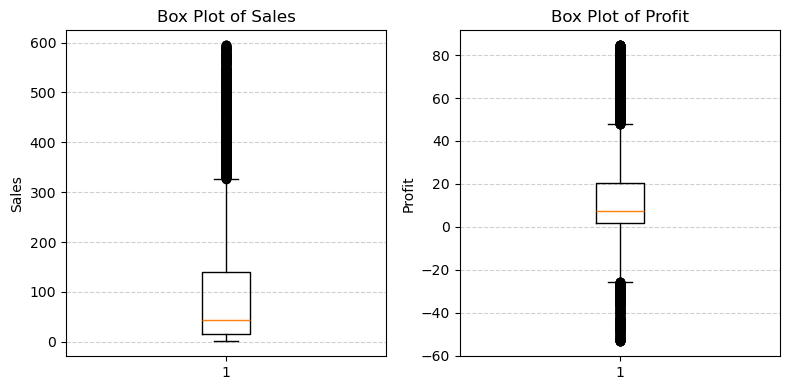

In [14]:
Q1s = df['Sales'].quantile(0.25)
Q3s = df['Sales'].quantile(0.75)
IQRs = Q3s - Q1s
lower_bs = Q1s - IQRs*2
upper_bs = Q3s + IQRs*2

Q1p = df['Profit'].quantile(0.25)
Q3p = df['Profit'].quantile(0.75)
IQRp = Q3p - Q1p
lower_bp = Q1p - IQRp*2
upper_bp = Q3p + IQRp*2


sales = df[(df['Sales']>=lower_bs)&(df['Sales']<=upper_bs)]['Sales']
profit = df[(df['Profit']>=lower_bp)&(df['Profit']<=upper_bp)]['Profit']

###cleaning outliner 

fig, axes = plt.subplots(1, 2, figsize=(8,4))

axes[0].boxplot(sales)
axes[0].set_title('Box Plot of Sales')
axes[0].set_ylabel('Sales')
axes[0].grid(axis='y', ls='--', alpha=0.6)


axes[1].boxplot(profit)
axes[1].set_title('Box Plot of Profit')
axes[1].set_ylabel('Profit')
axes[1].grid(axis='y', ls='--', alpha=0.6)

plt.tight_layout()
plt.show()


## Exercise 8

จงวาดกราฟแท่งแสดงจำนวน Furniture ที่ขายได้ในแต่ละไตรมาส (จำนวนให้นับจาก Quantity)

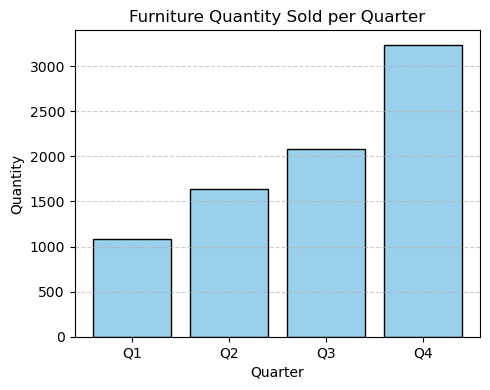

In [15]:
fur = df.loc[df['Category'] == 'Furniture'].copy()
quarters = []

for m in fur['Month']:
    if m in [1, 2, 3]:
        quarters.append('Q1')
    elif m in [4, 5, 6]:
        quarters.append('Q2')
    elif m in [7, 8, 9]:
        quarters.append('Q3')
    else:
        quarters.append('Q4')

fur['Quarter'] = quarters

q1 = fur[fur['Quarter'] == 'Q1']['Quantity'].sum()
q2 = fur[fur['Quarter'] == 'Q2']['Quantity'].sum()
q3 = fur[fur['Quarter'] == 'Q3']['Quantity'].sum()
q4 = fur[fur['Quarter'] == 'Q4']['Quantity'].sum()


plt.figure(figsize=(5,4))
plt.bar(['Q1','Q2','Q3','Q4'], [q1, q2, q3, q4],color='#9AD0EC', edgecolor='black')

plt.xlabel('Quarter')
plt.ylabel('Quantity')
plt.title('Furniture Quantity Sold per Quarter')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()